In [31]:
#pip install lightgbm


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor

In [33]:
# 1. Load dữ liệu
df = pd.read_csv('../../data/processed/training_data_final.csv', parse_dates=['Datetime'], index_col='Datetime')

In [34]:
# 2. FEATURE ENGINEERING (Tạo độ trễ trên GIÁ)
# Mục tiêu: Dùng giá của 1, 2, 3... phút trước để dự đoán giá phút hiện tại
cols = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target_col = 'Gold'

# Tạo Lag 1 đến Lag 3 (hoặc nhiều hơn nếu muốn)
for col in cols:
    for lag in [1, 2, 3]: # Dùng giá của 3 phút trước
        df[f'{col}_Lag{lag}'] = df[col].shift(lag)

# Xóa các dòng NaN sinh ra do shift
df.dropna(inplace=True)

# 3. CHUẨN BỊ X và y
# Input (X): Tất cả các cột Lag
feature_cols = [c for c in df.columns if 'Lag' in c]
X = df[feature_cols]

# Output (y): Giá vàng hiện tại (Raw Price)
y = df[target_col]

print("✅ Đã load dữ liệu Giá USD thành công!")
print(f"Kích thước dữ liệu: {df.shape}")
print(df.head())

✅ Đã load dữ liệu Giá USD thành công!
Kích thước dữ liệu: (177859, 20)
                        Gold   Silver    Brent     Wheat  USD index  \
Datetime                                                              
2025-11-28 09:54:40  4189.25  54.0125  62.8905  522.0042    0.80527   
2025-11-28 09:54:50  4189.25  54.0125  62.8905  522.0042    0.80527   
2025-11-28 09:55:00  4189.39  54.0125  62.8905  522.0042    0.80528   
2025-11-28 09:55:10  4189.33  54.0125  62.8905  522.0042    0.80530   
2025-11-28 09:55:20  4188.63  54.0125  62.8905  522.0042    0.80530   

                     Gold_Lag1  Gold_Lag2  Gold_Lag3  Brent_Lag1  Brent_Lag2  \
Datetime                                                                       
2025-11-28 09:54:40    4189.27    4189.27    4189.25     62.8905     62.8905   
2025-11-28 09:54:50    4189.25    4189.27    4189.27     62.8905     62.8905   
2025-11-28 09:55:00    4189.25    4189.25    4189.27     62.8905     62.8905   
2025-11-28 09:55:10    4189.39 

In [35]:
from sklearn.preprocessing import MinMaxScaler

# 1. Chia Train/Test (80-20) - Không shuffle vì là Time Series
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 2. Scaling (Chuẩn hóa về 0-1)
# Scale Features (X)
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale Target (y) - QUAN TRỌNG ĐỂ INVERSE SAU NÀY
scaler_y = MinMaxScaler()
# Reshape về 2D để fit
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Ravel lại về 1D cho LGBM (LGBM cần mảng 1 chiều cho y)
y_train_scaled = y_train_scaled.ravel()
y_test_scaled = y_test_scaled.ravel()

print("✅ Đã chia và chuẩn hóa dữ liệu.")

✅ Đã chia và chuẩn hóa dữ liệu.


In [36]:
# Khởi tạo mô hình
model = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)

# Train trên dữ liệu đã scale
model.fit(X_train_scaled, y_train_scaled)

print("✅ Huấn luyện xong!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2745
[LightGBM] [Info] Number of data points in the train set: 142287, number of used features: 15
[LightGBM] [Info] Start training from score 0.601193
✅ Huấn luyện xong!


In [37]:
# 6. DỰ ĐOÁN
y_pred = model.predict(X_test_scaled)

c:\Users\minam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [38]:
# 7. ĐÁNH GIÁ MÔ HÌNH
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 4243.664081905901
R² Score: -5061.909411822023


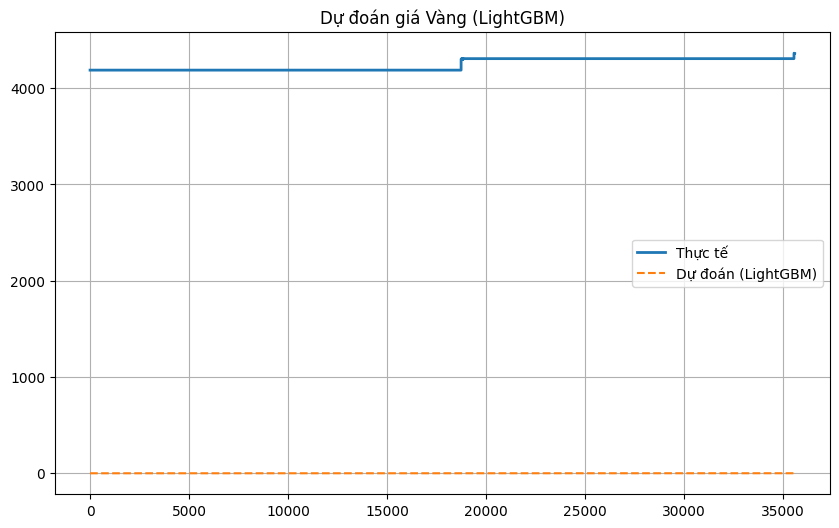

In [39]:
# 8. VẼ ĐỒ THỊ DỰ ĐOÁN
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Thực tế', linewidth=2)
plt.plot(y_pred, label='Dự đoán (LightGBM)', linestyle='--')
plt.title("Dự đoán giá Vàng (LightGBM)")
plt.legend()
plt.grid(True)
plt.show()

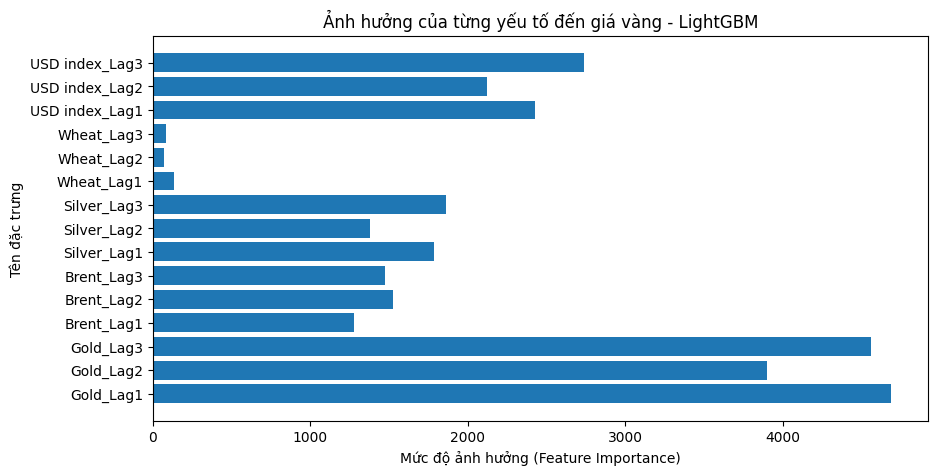

In [40]:
# 9. FEATURE IMPORTANCE
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, importance)
plt.xlabel("Mức độ ảnh hưởng (Feature Importance)")
plt.ylabel("Tên đặc trưng")
plt.title("Ảnh hưởng của từng yếu tố đến giá vàng - LightGBM")
plt.show()

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

# 1. Load data gốc (để lấy thông tin min/max của giá Vàng thật)
# Bạn sửa lại đường dẫn đúng tới file data sạch của bạn
path_data = '../../data/raw/data_price_realtime.csv' # Hoặc file data_final của bạn
df_raw = pd.read_csv(path_data, parse_dates=['Datetime'], index_col='Datetime')

# 2. Tạo một Scaler riêng chỉ cho cột Gold (Target)
# Việc này giúp việc inverse_transform không bị lỗi kích thước
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(df_raw[['Gold']]) # Học min/max của cột Gold

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [42]:
# 1. Dự báo (Kết quả đang ở dạng Scaled 0-1)
y_pred_scaled = model.predict(X_test_scaled)

# 2. Đảo ngược chuẩn hóa (Về giá USD)
# Dùng scaler_y đã fit ở trên
pred_usd = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
actual_usd = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)) # Hoặc lấy y_test gốc

# 3. Lưu kết quả
result_df = pd.DataFrame({
    'Datetime': y_test.index,
    'Actual': actual_usd.flatten(),
    'Predicted': pred_usd.flatten()
})

# Lưu file
import os
save_path = '../../results/predictions/LGBM.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"✅ Đã lưu kết quả (USD) vào: {save_path}")
print(result_df.tail())

c:\Users\minam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ Đã lưu kết quả (USD) vào: ../../results/predictions/LGBM.csv
                 Datetime   Actual    Predicted
35567 2025-12-18 23:57:00  4357.14  4212.879512
35568 2025-12-18 23:57:10  4358.14  4212.879512
35569 2025-12-18 23:57:20  4359.20  4212.879512
35570 2025-12-18 23:57:30  4359.63  4212.879512
35571 2025-12-18 23:57:40  4359.63  4212.879512
